In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os

target_stage=4
num_action_files=400
num_stage_rows=5105
num_samples=5105, num_joints=10


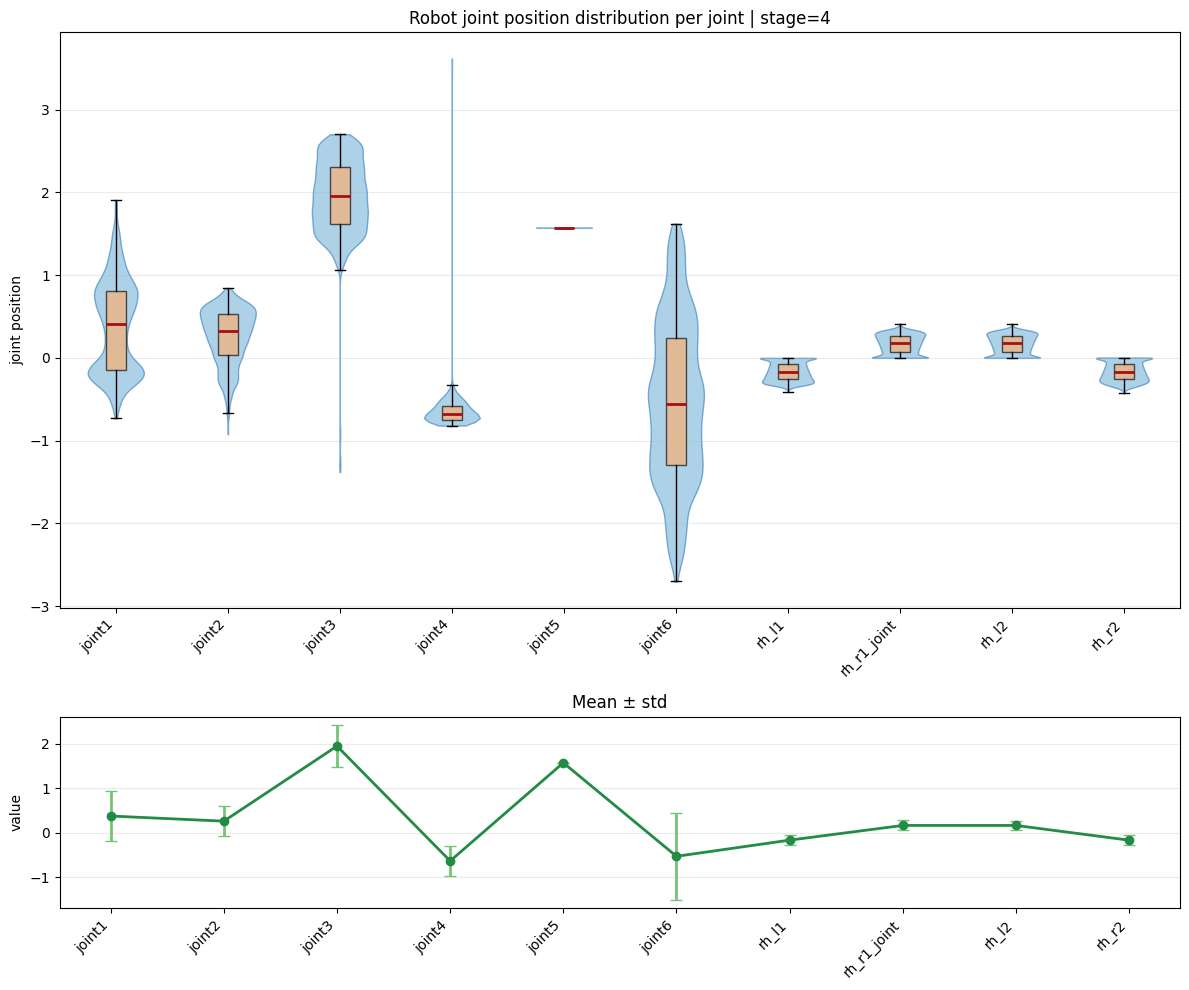

joint1: mean=0.3759, std=0.5572, min=-0.7282, max=1.9020
joint2: mean=0.2613, std=0.3351, min=-0.9216, max=0.8402
joint3: mean=1.9451, std=0.4671, min=-1.3801, max=2.7011
joint4: mean=-0.6321, std=0.3312, min=-0.8175, max=3.6169
joint5: mean=1.5709, std=0.0006, min=1.5694, max=1.5732
joint6: mean=-0.5278, std=0.9710, min=-2.7005, max=1.6198
rh_l1: mean=-0.1646, std=0.1105, min=-0.4091, max=0.0000
rh_r1_joint: mean=0.1650, std=0.1111, min=0.0000, max=0.4142
rh_l2: mean=0.1648, std=0.1108, min=-0.0002, max=0.4121
rh_r2: mean=-0.1658, std=0.1124, min=-0.4278, max=0.0044


In [21]:
# 특정 stage의 robot joint position 분포 시각화
# - 실제 데이터 구조: data["robot"]["joint_positions"], data["robot"]["joint_names"]
# - violin + box plot 으로 joint별 분포 형태를 보고
# - 아래 mean ± std 로 중심과 퍼짐을 함께 확인
root_path  ="/nas/Dataset/VLA/UON/Isaacsim/OMY_apple_picking/auto_fixed_place_ALL"
target_stage = 4
action_dir = os.path.join(root_path, "action")
action_list = sorted(os.listdir(action_dir))

joint_samples = []
joint_names = None
num_stage_rows = 0

for action_file in action_list:
    with open(os.path.join(action_dir, action_file), "r") as f:
        action_data = json.load(f)

    for data in action_data:
        if data.get("stage") != target_stage:
            continue

        robot = data.get("robot", {})
        joint_positions = robot.get("joint_positions")
        if joint_positions is None:
            continue

        if joint_names is None:
            joint_names = robot.get("joint_names")

        joint_samples.append(joint_positions)
        num_stage_rows += 1

joint_samples = np.asarray(joint_samples, dtype=np.float32)

if joint_samples.size == 0:
    print(f"No robot joint position samples found for stage={target_stage}")
else:
    if joint_samples.ndim == 1:
        joint_samples = joint_samples[:, None]

    num_samples, num_joints = joint_samples.shape
    if joint_names is None or len(joint_names) != num_joints:
        joint_names = [f"joint_{i}" for i in range(num_joints)]

    joint_means = joint_samples.mean(axis=0)
    joint_stds = joint_samples.std(axis=0)

    print(f"target_stage={target_stage}")
    print(f"num_action_files={len(action_list)}")
    print(f"num_stage_rows={num_stage_rows}")
    print(f"num_samples={num_samples}, num_joints={num_joints}")

    fig, axes = plt.subplots(
        2, 1, figsize=(max(12, num_joints * 1.2), 10), gridspec_kw={"height_ratios": [3, 1]}
    )

    # joint별 전체 분포 형태
    violin = axes[0].violinplot(
        [joint_samples[:, i] for i in range(num_joints)],
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in violin["bodies"]:
        body.set_facecolor("#6baed6")
        body.set_edgecolor("#2171b5")
        body.set_alpha(0.55)

    box = axes[0].boxplot(
        [joint_samples[:, i] for i in range(num_joints)],
        widths=0.18,
        patch_artist=True,
        showfliers=False,
    )
    for patch in box["boxes"]:
        patch.set_facecolor("#fdae6b")
        patch.set_alpha(0.65)
    for median in box["medians"]:
        median.set_color("#a50f15")
        median.set_linewidth(2.0)

    axes[0].set_title(f"Robot joint position distribution per joint | stage={target_stage}")
    axes[0].set_ylabel("joint position")
    axes[0].set_xticks(np.arange(1, num_joints + 1))
    axes[0].set_xticklabels(joint_names, rotation=45, ha="right")
    axes[0].grid(True, axis="y", alpha=0.25)

    # 평균과 표준편차
    x = np.arange(num_joints)
    axes[1].errorbar(
        x,
        joint_means,
        yerr=joint_stds,
        fmt="o-",
        capsize=4,
        color="#238b45",
        ecolor="#74c476",
        linewidth=2,
    )
    axes[1].set_title("Mean ± std")
    axes[1].set_ylabel("value")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(joint_names, rotation=45, ha="right")
    axes[1].grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    for i, name in enumerate(joint_names):
        print(
            f"{name}: mean={joint_means[i]:.4f}, std={joint_stds[i]:.4f}, "
            f"min={joint_samples[:, i].min():.4f}, max={joint_samples[:, i].max():.4f}"
        )


target_stage=4
num_action_files=400
num_stage_rows=5105


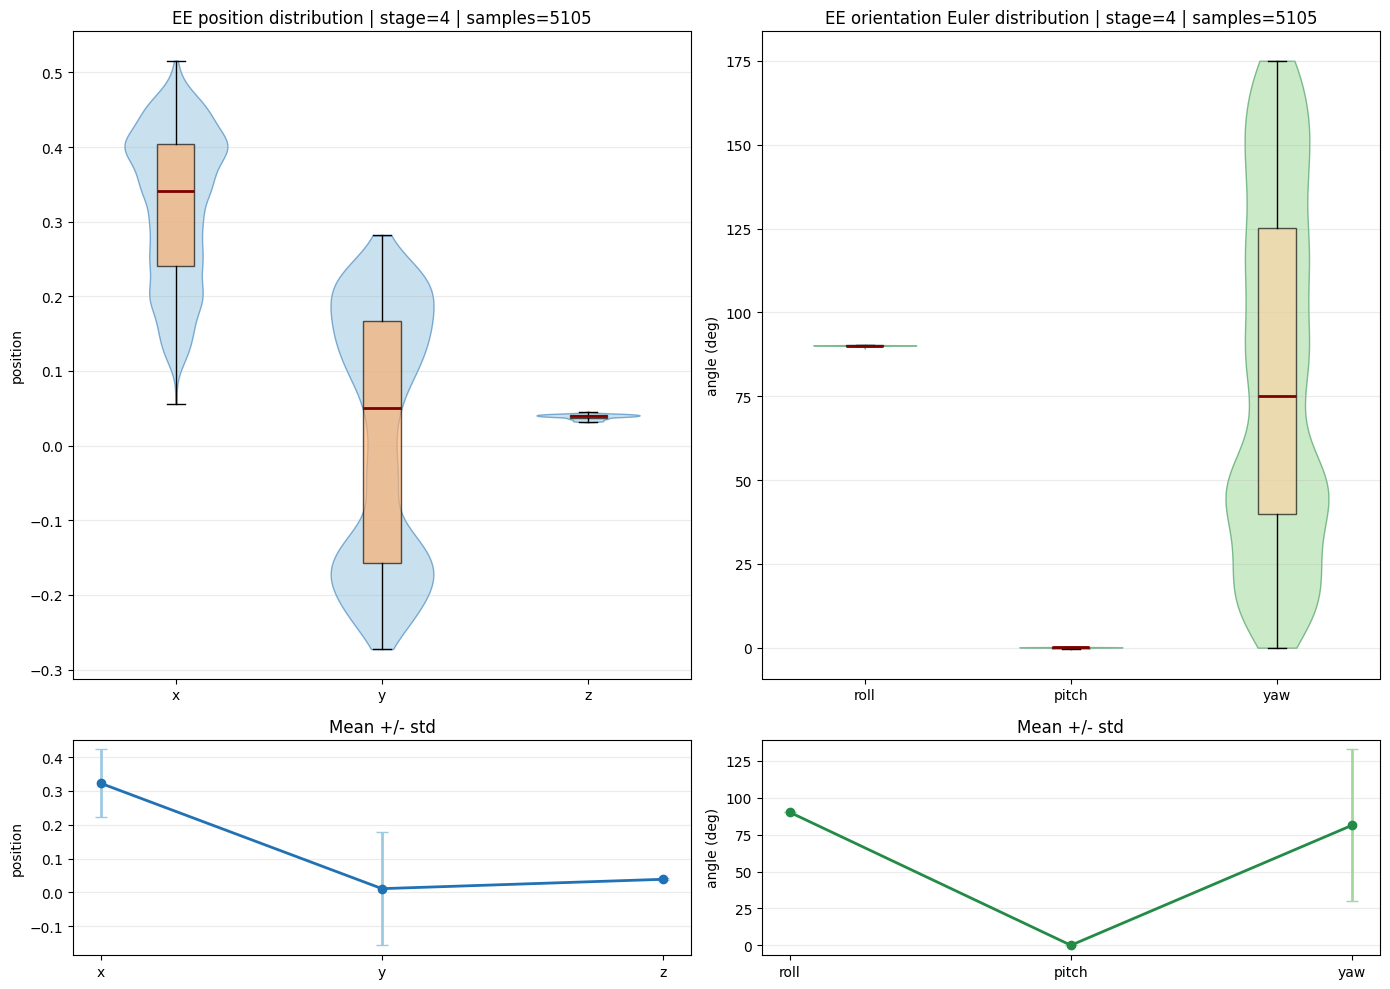


[EE Position Summary]
x: mean=0.3224, std=0.1005, min=0.0562, max=0.5157
y: mean=0.0113, std=0.1679, min=-0.2726, max=0.2816
z: mean=0.0390, std=0.0031, min=0.0313, max=0.0454

[EE Orientation Euler Summary | deg]
roll: mean=90.1084, std=0.1002, min=89.2028, max=90.3760
pitch: mean=0.0536, std=0.1373, min=-0.3826, max=0.3838
yaw: mean=81.2950, std=51.4698, min=0.0147, max=175.0236


In [22]:
# 특정 stage의 ee_position / ee_orientation(Euler) 분포 시각화
# - 전체 데이터에서 stage == target_stage 인 샘플만 사용
# - ee_position 은 x/y/z, ee_orientation 은 ee_quat(w/x/y/z)를 Euler(roll/pitch/yaw)로 변환해 시각화

def plot_distribution_with_summary(ax_dist, ax_stat, samples, labels, title, ylabel, violin_color, box_color, line_color):
    samples = np.asarray(samples, dtype=np.float32)
    if samples.ndim == 1:
        samples = samples[:, None]

    num_samples, num_dims = samples.shape
    means = samples.mean(axis=0)
    stds = samples.std(axis=0)

    violin = ax_dist.violinplot(
        [samples[:, i] for i in range(num_dims)],
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in violin["bodies"]:
        body.set_facecolor(violin_color)
        body.set_edgecolor(line_color)
        body.set_alpha(0.55)

    box = ax_dist.boxplot(
        [samples[:, i] for i in range(num_dims)],
        widths=0.18,
        patch_artist=True,
        showfliers=False,
    )
    for patch in box["boxes"]:
        patch.set_facecolor(box_color)
        patch.set_alpha(0.65)
    for median in box["medians"]:
        median.set_color("#7f0000")
        median.set_linewidth(2.0)

    ax_dist.set_title(f"{title} | stage={target_stage} | samples={num_samples}")
    ax_dist.set_ylabel(ylabel)
    ax_dist.set_xticks(np.arange(1, num_dims + 1))
    ax_dist.set_xticklabels(labels)
    ax_dist.grid(True, axis="y", alpha=0.25)

    x = np.arange(num_dims)
    ax_stat.errorbar(
        x,
        means,
        yerr=stds,
        fmt="o-",
        capsize=4,
        color=line_color,
        ecolor=violin_color,
        linewidth=2,
    )
    ax_stat.set_title("Mean +/- std")
    ax_stat.set_ylabel(ylabel)
    ax_stat.set_xticks(x)
    ax_stat.set_xticklabels(labels)
    ax_stat.grid(True, axis="y", alpha=0.25)

    return means, stds


def quaternion_wxyz_to_euler_rpy_deg(quaternions):
    quaternions = np.asarray(quaternions, dtype=np.float32)
    if quaternions.ndim == 1:
        quaternions = quaternions[None, :]

    qw = quaternions[:, 0]
    qx = quaternions[:, 1]
    qy = quaternions[:, 2]
    qz = quaternions[:, 3]

    sinr_cosp = 2.0 * (qw * qx + qy * qz)
    cosr_cosp = 1.0 - 2.0 * (qx * qx + qy * qy)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    sinp = 2.0 * (qw * qy - qz * qx)
    sinp = np.clip(sinp, -1.0, 1.0)
    pitch = np.arcsin(sinp)

    siny_cosp = 2.0 * (qw * qz + qx * qy)
    cosy_cosp = 1.0 - 2.0 * (qy * qy + qz * qz)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    euler_rad = np.stack([roll, pitch, yaw], axis=1)
    return np.degrees(euler_rad)


action_dir = os.path.join(root_path, "action")
action_list = sorted(os.listdir(action_dir))

ee_positions = []
ee_quaternions = []
num_stage_rows = 0

for action_file in action_list:
    with open(os.path.join(action_dir, action_file), "r") as f:
        action_data = json.load(f)

    for data in action_data:
        if data.get("stage") != target_stage:
            continue

        robot = data.get("robot", {})
        ee_position = robot.get("ee_position")
        ee_orientation = robot.get("ee_quat")

        if ee_position is None or ee_orientation is None:
            continue

        ee_positions.append(ee_position)
        ee_quaternions.append(ee_orientation)
        num_stage_rows += 1

ee_positions = np.asarray(ee_positions, dtype=np.float32)
ee_quaternions = np.asarray(ee_quaternions, dtype=np.float32)

if ee_positions.size == 0 or ee_quaternions.size == 0:
    print(f"No ee samples found for stage={target_stage}")
else:
    ee_euler_deg = quaternion_wxyz_to_euler_rpy_deg(ee_quaternions)
    ee_pos_labels = ["x", "y", "z"]
    ee_ori_labels = ["roll", "pitch", "yaw"]

    print(f"target_stage={target_stage}")
    print(f"num_action_files={len(action_list)}")
    print(f"num_stage_rows={num_stage_rows}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

    ee_pos_means, ee_pos_stds = plot_distribution_with_summary(
        axes[0, 0],
        axes[1, 0],
        ee_positions,
        ee_pos_labels,
        title="EE position distribution",
        ylabel="position",
        violin_color="#9ecae1",
        box_color="#fdae6b",
        line_color="#2171b5",
    )

    ee_ori_means, ee_ori_stds = plot_distribution_with_summary(
        axes[0, 1],
        axes[1, 1],
        ee_euler_deg,
        ee_ori_labels,
        title="EE orientation Euler distribution",
        ylabel="angle (deg)",
        violin_color="#a1d99b",
        box_color="#fdd0a2",
        line_color="#238b45",
    )

    plt.tight_layout()
    plt.show()

    print("\n[EE Position Summary]")
    for i, name in enumerate(ee_pos_labels):
        print(
            f"{name}: mean={ee_pos_means[i]:.4f}, std={ee_pos_stds[i]:.4f}, "
            f"min={ee_positions[:, i].min():.4f}, max={ee_positions[:, i].max():.4f}"
        )

    print("\n[EE Orientation Euler Summary | deg]")
    for i, name in enumerate(ee_ori_labels):
        print(
            f"{name}: mean={ee_ori_means[i]:.4f}, std={ee_ori_stds[i]:.4f}, "
            f"min={ee_euler_deg[:, i].min():.4f}, max={ee_euler_deg[:, i].max():.4f}"
        )
